Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== HỆ THỐNG 1: LIGHTGBM ĐỘC LẬP ===
1. Khai bao duong dan truc tiep tu Google Drive...
2. Doc tap TRAIN truc tiep tu Drive...
3. Huan luyen LightGBM voi bo tham so toi uu...
[LightGBM] [Info] Number of positive: 20900, number of negative: 209701
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067037 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1936
[LightGBM] [Info] Number of data points in the train set: 230601, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090633 -> initscore=-2.305934
[LightGBM] [Info] Start training from score -2.305934
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

/tmp/ipykernel_3528/1966078253.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_percentage', y='feature', data=df_importance, palette='viridis')


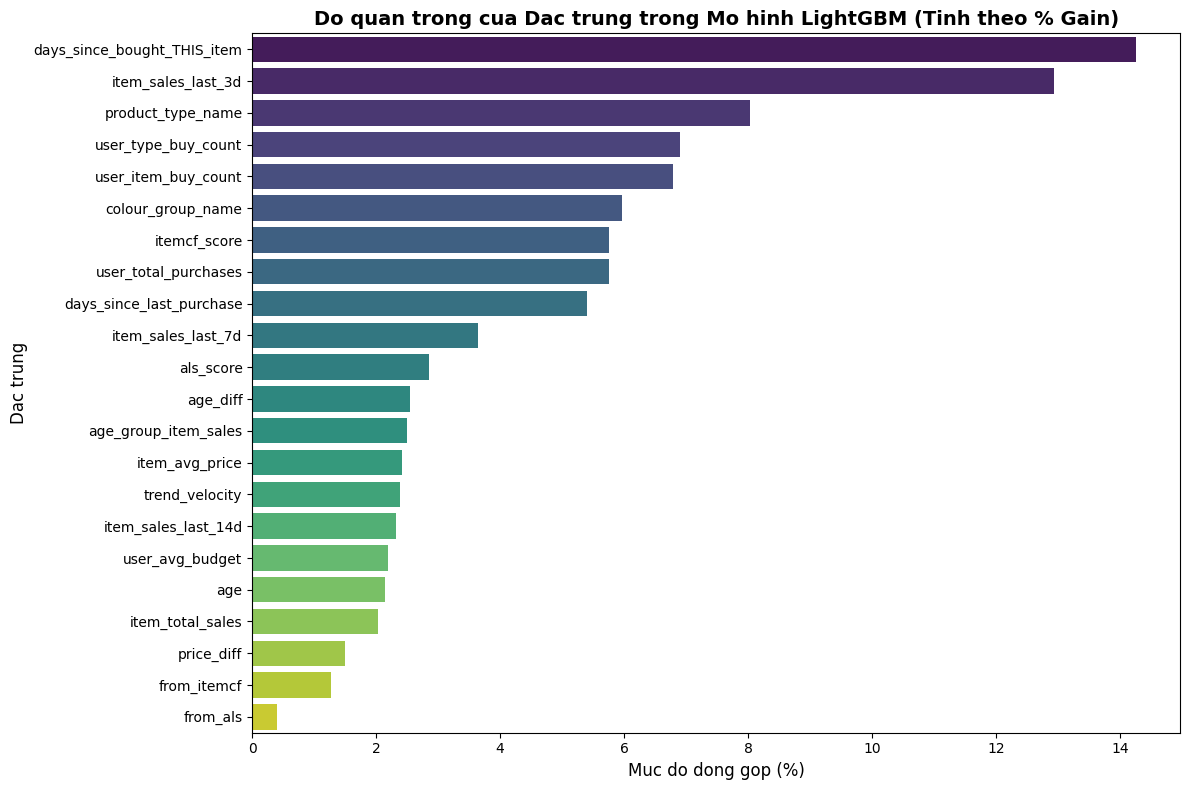

In [ ]:
!pip install lightgbm pandas pyarrow matplotlib seaborn -q
from google.colab import drive
drive.mount('/content/drive')

import os, gc
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

print("=== HỆ THỐNG 1: LIGHTGBM ĐỘC LẬP ===")
print("1. Khai bao duong dan truc tiep tu Google Drive...")
DRIVE_TRAIN = "/content/drive/MyDrive/HM-DATA/outputs_v2/master/train_enriched_temp.parquet"

# DANH SÁCH 22 ĐẶC TRƯNG CHUẨN
features = [
    'age', 'item_total_sales', 'item_avg_price',
    'user_total_purchases', 'user_avg_budget', 'user_item_buy_count',
    'days_since_last_purchase', 'days_since_bought_THIS_item',
    'item_sales_last_3d', 'item_sales_last_7d', 'item_sales_last_14d',
    'trend_velocity', 'age_group_item_sales', 'user_type_buy_count',
    'age_diff', 'price_diff',
    'from_als', 'from_itemcf', 'als_score', 'itemcf_score',
    'product_type_name', 'colour_group_name'
]

categorical_features = ['product_type_name', 'colour_group_name']

def downcast(df):
    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes('int64').columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

print("2. Doc tap TRAIN truc tiep tu Drive...")
cols_train = features + ['label', 'customer_id']
pdf_train = pd.read_parquet(DRIVE_TRAIN, columns=cols_train)
pdf_train = downcast(pdf_train)

for col in categorical_features:
    pdf_train[col] = pdf_train[col].astype('category')

X_train = pdf_train[features]
y_train = pdf_train['label']
del pdf_train; gc.collect()

print("3. Huan luyen LightGBM voi bo tham so toi uu...")
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features, free_raw_data=True)
del X_train, y_train; gc.collect()

params = {
    'objective': 'binary', 'metric': 'auc', 'n_estimators': 400,
    'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 8,
    'scale_pos_weight': 10.0, 'min_child_samples': 100,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'random_state': 42, 'n_jobs': -1, 'max_bin': 127
}

booster = lgb.train(params, dtrain, callbacks=[lgb.log_evaluation(50)])
del dtrain; gc.collect()

booster.save_model('/content/lightgbm_model.txt')
print("Da luu mo hinh vao /content/lightgbm_model.txt. RAM hoan toan trong ranh!")

print("\n4. Ve bieu do Feature Importance (Gain)...")
importance_gain = booster.feature_importance(importance_type='gain')
df_importance = pd.DataFrame({'feature': booster.feature_name(), 'importance_gain': importance_gain})
df_importance['importance_percentage'] = (df_importance['importance_gain'] / df_importance['importance_gain'].sum()) * 100
df_importance = df_importance.sort_values('importance_percentage', ascending=False)

print("\n--- BANG XEP HANG TAM QUAN TRONG CUA DAC TRUNG ---")
print(df_importance[['feature', 'importance_percentage']].to_string(index=False, float_format="%.2f%%"))

plt.figure(figsize=(12, 8))
sns.barplot(x='importance_percentage', y='feature', data=df_importance, palette='viridis')
plt.title('Do quan trong cua Dac trung trong Mo hinh LightGBM (Tinh theo % Gain)', fontsize=14, fontweight='bold')
plt.xlabel('Muc do dong gop (%)', fontsize=12)
plt.ylabel('Dac trung', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import os, gc, shutil
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import pyarrow as pa
import lightgbm as lgb
import pandas as pd

DRIVE_TEST = "/content/drive/MyDrive/HM-DATA/outputs_v2/master/test_enriched_temp.parquet"

# Chiến thuật chống sập mạng: Ghi Local, Copy Drive
LOCAL_PREDS_LGBM = '/content/test_predictions_lgbm_temp.parquet'
DRIVE_PREDS_LGBM = '/content/drive/MyDrive/HM-DATA/outputs_v2/master/test_predictions_lgbm.parquet'

print("5. Load lai mo hinh va chuan bi doc tap TEST...")
booster = lgb.Booster(model_file='/content/lightgbm_model.txt')
cols_test = features + ['customer_id', 'article_id']

dataset = ds.dataset(DRIVE_TEST, format="parquet", ignore_prefixes=['.', '_'])
writer = None
batch_count = 0

print("6. Dang du doan cuon chieu tung lo (Ghi xuong Local Disk)...")
for batch in dataset.to_batches(columns=cols_test, batch_size=2_000_000):
    batch_count += 1
    print(f"   -> Dang xu ly Lo {batch_count}...")

    df_batch = batch.to_pandas()
    # Tu dong downcast
    for col in df_batch.select_dtypes('float64').columns:
        df_batch[col] = df_batch[col].astype('float32')
    for col in df_batch.select_dtypes('int64').columns:
        df_batch[col] = pd.to_numeric(df_batch[col], downcast='integer')

    for col in categorical_features:
        df_batch[col] = df_batch[col].astype('category')

    df_batch['buy_prob'] = booster.predict(df_batch[features])
    res_batch = df_batch[['customer_id', 'article_id', 'buy_prob']]

    table = pa.Table.from_pandas(res_batch)
    if writer is None:
        writer = pq.ParquetWriter(LOCAL_PREDS_LGBM, table.schema)
    writer.write_table(table)

    del df_batch, res_batch, table, batch; gc.collect()

if writer is not None:
    writer.close()
del booster; gc.collect()

print("7. Sao chep file hoan chinh sang Google Drive...")
os.makedirs(os.path.dirname(DRIVE_PREDS_LGBM), exist_ok=True)
shutil.copy(LOCAL_PREDS_LGBM, DRIVE_PREDS_LGBM)

if os.path.exists(LOCAL_PREDS_LGBM):
    os.remove(LOCAL_PREDS_LGBM)

print(f"Du doan hoan tat va da luu an toan tai: {DRIVE_PREDS_LGBM}")

5. Load lai mo hinh va chuan bi doc tap TEST...
6. Dang du doan cuon chieu tung lo (Ghi xuong Local Disk)...
   -> Dang xu ly Lo 1...
   -> Dang xu ly Lo 2...
   -> Dang xu ly Lo 3...
   -> Dang xu ly Lo 4...
   -> Dang xu ly Lo 5...
   -> Dang xu ly Lo 6...
   -> Dang xu ly Lo 7...
   -> Dang xu ly Lo 8...
   -> Dang xu ly Lo 9...
   -> Dang xu ly Lo 10...
   -> Dang xu ly Lo 11...
   -> Dang xu ly Lo 12...
   -> Dang xu ly Lo 13...
   -> Dang xu ly Lo 14...
   -> Dang xu ly Lo 15...
   -> Dang xu ly Lo 16...
   -> Dang xu ly Lo 17...
   -> Dang xu ly Lo 18...
   -> Dang xu ly Lo 19...
   -> Dang xu ly Lo 20...
   -> Dang xu ly Lo 21...
   -> Dang xu ly Lo 22...
   -> Dang xu ly Lo 23...
   -> Dang xu ly Lo 24...
   -> Dang xu ly Lo 25...
   -> Dang xu ly Lo 26...
   -> Dang xu ly Lo 27...
   -> Dang xu ly Lo 28...
   -> Dang xu ly Lo 29...
   -> Dang xu ly Lo 30...
   -> Dang xu ly Lo 31...
   -> Dang xu ly Lo 32...
   -> Dang xu ly Lo 33...
   -> Dang xu ly Lo 34...
   -> Dang xu ly

In [ ]:
import pandas as pd
import numpy as np
import datetime
import math
import gc

print("8. Xep hang va Tinh toan Da chi so (LightGBM Doc Lap)...")
DRIVE_TRANS = "/content/drive/MyDrive/HM-DATA/processed_v2/cleaned_transactions.parquet"
DRIVE_CUST_RAW = "/content/drive/MyDrive/HM-DATA/raw/customers.csv"
DRIVE_PREDS_LGBM = '/content/drive/MyDrive/HM-DATA/outputs_v2/master/test_predictions_lgbm.parquet'

print("   -> Dang doc Ground Truth Tuan 8...")
df_dates = pd.read_parquet(DRIVE_TRANS, columns=['t_dat_date'])
max_date = df_dates['t_dat_date'].max()
test_start = max_date - datetime.timedelta(days=7)
decay_start = test_start - datetime.timedelta(days=21)
del df_dates; gc.collect()

transactions = pd.read_parquet(
    DRIVE_TRANS, columns=['t_dat_date', 'customer_id', 'article_id'],
    filters=[('t_dat_date', '>=', test_start)]
)
actual_grouped = transactions.groupby('customer_id')['article_id'].agg(set).reset_index(name='actual_items')
del transactions; gc.collect()

print("   -> Dang doc thong tin Khach hang de chia Nhom Tuoi...")
customers = pd.read_csv(DRIVE_CUST_RAW, usecols=['customer_id', 'age'])

def categorize_age(age):
    if pd.isna(age): return 'Unknown'
    if age < 25: return '<25'
    if age <= 35: return '25-35'
    if age <= 45: return '36-45'
    if age <= 55: return '46-55'
    return '>55'

customers['age_group'] = customers['age'].apply(categorize_age)

print("   -> Dang tinh toan Time-Decayed Bestseller (He so 0.95)...")
trend_df = pd.read_parquet(
    DRIVE_TRANS, columns=['t_dat_date', 'customer_id', 'article_id'],
    filters=[('t_dat_date', '>=', decay_start), ('t_dat_date', '<', test_start)]
)

test_start_dt = pd.to_datetime(test_start)
trend_df['days_ago'] = (test_start_dt - pd.to_datetime(trend_df['t_dat_date'])).dt.days
trend_df['weight'] = 0.95 ** trend_df['days_ago']

global_scores = trend_df.groupby('article_id')['weight'].sum()
global_top_12 = global_scores.nlargest(12).index.tolist()
del global_scores; gc.collect()

trend_df = trend_df.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')
trend_df['age_group'] = trend_df['age_group'].fillna('Unknown')

age_scores = trend_df.groupby(['age_group', 'article_id'])['weight'].sum().reset_index()
age_bestsellers = {}
for age_grp, grp_data in age_scores.groupby('age_group'):
    age_bestsellers[age_grp] = grp_data.nlargest(12, 'weight')['article_id'].tolist()

if 'Unknown' not in age_bestsellers or len(age_bestsellers['Unknown']) < 12:
    age_bestsellers['Unknown'] = global_top_12
del trend_df, age_scores; gc.collect()

print("   -> Dang doc file du doan cua LightGBM tu Drive...")
# FIX LỖI Ở ĐÂY: Đọc đúng file từ Google Drive thay vì file local không tồn tại
test_ids = pd.read_parquet(DRIVE_PREDS_LGBM)
test_ids = test_ids.sort_values(['customer_id', 'buy_prob', 'article_id'], ascending=[True, False, True])
top12_df = test_ids.groupby('customer_id').head(12)
del test_ids; gc.collect()

top12_preds = top12_df.groupby('customer_id')['article_id'].agg(list).reset_index(name='predicted_items')
del top12_df; gc.collect()

print("   -> Dang ghep noi va bom Fallback...")
eval_df = actual_grouped.merge(top12_preds, on='customer_id', how='left')
eval_df = eval_df.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')
eval_df['age_group'] = eval_df['age_group'].fillna('Unknown')
del actual_grouped, top12_preds, customers; gc.collect()

def fill_predictions(row):
    preds = row['predicted_items']
    age_grp = row['age_group']
    fallback_list = age_bestsellers.get(age_grp, global_top_12)

    if not isinstance(preds, list):
        return fallback_list
    if len(preds) < 12:
        needed = 12 - len(preds)
        fillers = [item for item in fallback_list if item not in preds][:needed]
        if len(fillers) < needed:
            extra_needed = needed - len(fillers)
            extra_fillers = [item for item in global_top_12 if item not in preds and item not in fillers][:extra_needed]
            fillers.extend(extra_fillers)
        return preds + fillers
    return preds[:12]

eval_df['predicted_items'] = eval_df.apply(fill_predictions, axis=1)

def calculate_all_metrics(row, k=12):
    actual = row['actual_items']
    predicted = row['predicted_items']

    hits, map_score, dcg = 0.0, 0.0, 0.0
    seen = set()

    for i, p in enumerate(predicted):
        if p in actual and p not in seen:
            hits += 1.0
            map_score += hits / (i + 1)
            dcg += 1.0 / math.log2(i + 2)
            seen.add(p)

    precision = hits / k
    recall = hits / len(actual)
    hit_rate = 1.0 if hits > 0 else 0.0
    map_score = map_score / min(len(actual), k)

    idcg = sum((1.0 / math.log2(i + 2)) for i in range(min(len(actual), k)))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    return pd.Series([map_score, ndcg, precision, recall, hit_rate],
                     index=['map@12', 'ndcg@12', 'precision@12', 'recall@12', 'hit_rate@12'])

print("   -> Dang cham diem (Tien trinh nay se chay khoang 1-2 phut)...")
metrics_df = eval_df.apply(calculate_all_metrics, axis=1)
eval_df = pd.concat([eval_df, metrics_df], axis=1)

print("\n" + "=" * 60)
print(f"   BẢNG ĐIỂM ĐÁNH GIÁ ĐỘC LẬP (LIGHTGBM)")
print("=" * 60)
print(f" Tổng số khách hàng Active   : {len(eval_df):,}")
print("-" * 60)
print(f" 1. MAP@12 (Kaggle Metric)   : {eval_df['map@12'].mean():.5f}")
print(f" 2. NDCG@12 (Xếp hạng)       : {eval_df['ndcg@12'].mean():.5f}")
print(f" 3. Hit Rate@12 (Tỷ lệ trúng): {eval_df['hit_rate@12'].mean():.2%}")
print("=" * 60)

8. Xep hang va Tinh toan Da chi so (LightGBM Doc Lap)...
   -> Dang doc Ground Truth Tuan 8...
   -> Dang doc thong tin Khach hang de chia Nhom Tuoi...
   -> Dang tinh toan Time-Decayed Bestseller (He so 0.95)...
   -> Dang doc file du doan cua LightGBM tu Drive...
   -> Dang ghep noi va bom Fallback...
   -> Dang cham diem (Tien trinh nay se chay khoang 1-2 phut)...

   BẢNG ĐIỂM ĐÁNH GIÁ ĐỘC LẬP (LIGHTGBM)
 Tổng số khách hàng Active   : 75,481
------------------------------------------------------------
 1. MAP@12 (Kaggle Metric)   : 0.02972
 2. NDCG@12 (Xếp hạng)       : 0.04357
 3. Hit Rate@12 (Tỷ lệ trúng): 12.12%
